# ROGII Wellbore Geology - Dense (MLP) Hyperparameter Optimization

Find the optimal Dense (MLP) network configuration using **Keras Tuner Hyperband**.

**Features (6):** `MD, X, Y, Z, GR, TVT_input`  
**Label:** `TVT`  
**Backend**: Keras 3 + JAX backend

**Author**: Samir Attrah

In [1]:
# Check GPU availability
import jax
print(f"JAX devices: {jax.devices()}")
import keras
print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.backend.backend()}")


JAX devices: [CudaDevice(id=0)]


2026-07-09 08:43:43.696940: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783575823.756128   25324 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783575823.771963   25324 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras version: 3.12.0
Keras backend: tensorflow


### 1. Environment & Imports
Setup JAX backend for Keras, import necessary libraries, and configure random seed values.

In [2]:
"""Environment setup and library imports for hyperparameter optimization of a Dense (MLP) model.

Sets Keras JAX backend and configures JAX precision and allocation behavior.
"""

import os

os.environ["KERAS_BACKEND"] = "jax"
# Preallocate most GPU memory so JAX avoids slow per-step allocations during tuning.
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "true"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.90"
os.environ.setdefault("XLA_FLAGS", "--xla_gpu_triton_gemm_any=True")

import jax

# Keep the search on float32/TF32. Consumer NVIDIA GPUs run float64 very slowly.
jax.config.update("jax_enable_x64", False)
jax.config.update("jax_default_matmul_precision", "tensorfloat32")

import keras
from keras import callbacks, layers, regularizers
import keras_tuner as kt
import jax.numpy as jnp
import numpy as np
import polars as pl
import glob
import pickle
import random
import warnings

warnings.filterwarnings("ignore")

# Show enough digits to round-trip float32 diagnostics
np.set_printoptions(precision=9, floatmode="unique")

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Keras backend : {keras.backend.backend()}")
print(f"Working dir   : {os.getcwd()}")
print(f"JAX devices   : {jax.devices()}")


Keras version : 3.12.0
Keras backend : tensorflow
Working dir   : /home/samer/Documents/competitions/ROGII/notebooks
JAX devices   : [CudaDevice(id=0)]


### 2. Auto-detect Dataset Path
Locate the competition dataset in local or Kaggle environments.

In [3]:
def find_data_dir():
    """Searches common Kaggle mount points for the ROGII dataset.

    Returns:
        str: Path to the dataset directory containing 'train' subdirectory.

    Raises:
        FileNotFoundError: If the dataset cannot be found in any candidate path.
    """
    candidates = [
        "/kaggle/input/competitions/rogii-wellbore-geology-prediction",
        "/kaggle/input/rogii-wellbore-geology-prediction",
        "/home/samer/Documents/competitions/ROGII/dataset",
    ]

    for scan_root in ["/kaggle/input", "/kaggle/input/competitions"]:
        if os.path.isdir(scan_root):
            for entry in os.listdir(scan_root):
                full = os.path.join(scan_root, entry)
                if os.path.isdir(full) and full not in candidates:
                    candidates.append(full)

    print("Searching for ROGII dataset...")
    for path in candidates:
        if not os.path.isdir(path):
            continue

        contents = os.listdir(path)
        has_train = "train" in contents and os.path.isdir(os.path.join(path, "train"))
        n_train = 0
        if has_train:
            n_train = len(
                glob.glob(os.path.join(path, "train", "*__horizontal_well.csv"))
            )

        if n_train > 0:
            print(f"  V Using {path} (found {n_train} train wells)")
            return path

    raise FileNotFoundError("Could not find ROGII dataset.")


DATA_DIR = find_data_dir()


Searching for ROGII dataset...
  V Using /home/samer/Documents/competitions/ROGII/dataset (found 773 train wells)


### 3. Data helpers & Preparation
Functions for loading well logs, preprocessing them with Polars, and standardizing them with JAX in float64 precision.

In [4]:
"""Data loading, preprocessing and preparation functions using Polars and JAX."""

FEATURE_COLS = ["MD", "X", "Y", "Z", "GR", "TVT_input"]
TARGET = "TVT"


def load_well(data_dir, filename, split="train", augmented=False):
    """Loads one horizontal well CSV as a Polars DataFrame.

    Args:
        data_dir: Path to the dataset (root/dataset).
        filename: Well filename (with extension).
        split: Folder split, either "train" or "test".
        augmented: Whether to load from the augmented directory.

    Returns:
        pl.DataFrame: Loaded well logs.
    """
    dataset_root = os.path.dirname(data_dir)
    
    if augmented:
        # Load from augmented directory
        path = os.path.join(dataset_root, "dataset_augmented", "train", filename)
    else:
        # Load from original directory
        path = os.path.join(data_dir, split, filename)
    
    return pl.read_csv(path, infer_schema_length=10000)


def preprocess(df):
    """Interpolates and fills null values in the feature columns."""
    for col in FEATURE_COLS:
        if col in df.columns:
            df = df.with_columns(
                pl.col(col)
                .interpolate()
                .fill_null(strategy="forward")
                .fill_null(strategy="backward")
                .fill_null(0.0)
            )
    return df


def prepare_data(data_dir, val_ratio=0.20, seed=42, max_wells=None):
    """Loads all horizontal wells exactly once and concatenates them."""
    dataset_root = os.path.dirname(data_dir)
    
    # 1. Get original training IDs
    pattern_train = os.path.join(data_dir, "train", "*__horizontal_well.csv")
    files_train = sorted([os.path.basename(f) for f in glob.glob(pattern_train)])
    
    # 2. Get augmented training files (ONLY the _aug.csv ones)
    # The script generated them with _aug.csv suffix.
    pattern_aug = os.path.join(dataset_root, "dataset_augmented", "train", "*__horizontal_well_aug.csv")
    files_aug = sorted([os.path.basename(f) for f in glob.glob(pattern_aug)])
    
    # Combined training file list (originals + new augmentations)
    files_train_all = files_train + files_aug

    pattern_test = os.path.join(data_dir, "test", "*__horizontal_well.csv")
    files_test = sorted([os.path.basename(f) for f in glob.glob(pattern_test)])

    # We include all for loading
    files_all = files_train_all + files_test

    if max_wells:
        files_all = files_all[:max_wells]

    np.random.seed(seed)
    # Only split among training files for validation
    n_val = max(1, int(len(files_train_all) * val_ratio))
    val_set = set(np.random.permutation(len(files_train_all))[:n_val])

    print(
        f"Loading {len(files_all)} wells total. "
        f"(Original Train: {len(files_train)}, Augmented: {len(files_aug)}, Test: {len(files_test)})."
    )

    def get_arrays(files):
        feats, tgts = [], []
        for filename in files:
            try:
                # Determine if it's from train, augmented, or test
                if filename in files_aug:
                    split = "train"
                    aug = True
                elif filename in files_train:
                    split = "train"
                    aug = False
                else:
                    split = "test"
                    aug = False

                df = preprocess(load_well(data_dir, filename, split=split, augmented=aug))

                # Only include target if available (train set)
                if TARGET in df.columns:
                    df = df.filter(pl.col(TARGET).is_not_null())
                    if len(df) == 0:
                        continue
                    tgts.append(df.select(TARGET).to_numpy().ravel().astype(np.float64))
                else:
                    continue

                feats.append(df.select(FEATURE_COLS).to_numpy().astype(np.float64))
            except Exception as e:
                print(f"  Skip {filename}: {e}")

        if not feats:
            return np.array([]), np.array([])
        return np.concatenate(feats), np.concatenate(tgts)

    train_files = [fname for i, fname in enumerate(files_train_all) if i not in val_set]
    val_files = [fname for i, fname in enumerate(files_train_all) if i in val_set]

    X_train_raw, y_train_raw = get_arrays(train_files)
    X_val_raw, y_val_raw = get_arrays(val_files)

    return (
        np.array(X_train_raw, dtype=np.float32),
        np.array(y_train_raw, dtype=np.float32),
        np.array(X_val_raw, dtype=np.float32),
        np.array(y_val_raw, dtype=np.float32),
        y_val_raw,
    )


print("Preparing dataset...")
X_train, y_train, X_val, y_val, y_val_raw = prepare_data(DATA_DIR)
X_train = np.ascontiguousarray(X_train, dtype=np.float32)
y_train = np.ascontiguousarray(y_train.reshape(-1, 1), dtype=np.float32)
X_val = np.ascontiguousarray(X_val, dtype=np.float32)
y_val = np.ascontiguousarray(y_val.reshape(-1, 1), dtype=np.float32)

# Keep the full arrays resident on the GPU instead of copying many small host batches.
X_train_device = jax.device_put(X_train)
y_train_device = jax.device_put(y_train)
X_val_device = jax.device_put(X_val)
y_val_device = jax.device_put(y_val)

SEARCH_BATCH_SIZE = 16 # min(16384, max(1024, len(X_train) // 8))
VAL_BATCH_SIZE = 16 # min(32768, max(2048, len(X_val)))
print(f"Train size: {X_train.shape}, Val size: {X_val.shape}")
print(f"Search batch size: {SEARCH_BATCH_SIZE:,}, validation batch size: {VAL_BATCH_SIZE:,}")


Preparing dataset...
Loading 1549 wells total. (Original Train: 773, Augmented: 773, Test: 3).
Train size: (7943325, 6), Val size: (1971680, 6)
Search batch size: 16, validation batch size: 16


### 4. Define HyperModel & Tuner
Specify the search space for layers count, units, regularization rate, dropout rates, learning rate, and gradient clipping norm using Keras Tuner Hyperband.

In [5]:
class DenseHyperModel(kt.HyperModel):
    """
    Hyperparameter search space for Multi-Layer Perceptron (MLP) model.

    Tunes depth, units per layer, activation function, kernel initializer,
    regularization, dropout, global gradient clipping, and Adam optimizer settings.
    """

    def __init__(self, input_dim):
        """Initializes the hypermodel.

        Args:
            input_dim: Input dimensionality.
        """
        super().__init__()
        self.input_dim = input_dim

    def build(self, hp):
        """Builds a dense neural network (MLP) with tunable hyperparameters.

        Args:
            hp: Keras Tuner HyperParameters container.

        Returns:
            keras.Model: Configured Keras Model instance.
        """
        model = keras.Sequential()
        model.add(layers.Input(shape=(self.input_dim,)))

        # Tune the number of hidden layers
        num_layers = hp.Int("num_layers", 8, 12, default=2)

        # Tune activation and initializer globally for all hidden layers
        activation = hp.Choice(
            "activation", ["linear", "relu", "selu", "tanh", "sigmoid"], default="relu"
        )
        initializer = hp.Choice(
            "initializer",
            ["glorot_uniform", "he_normal", "lecun_normal", "orthogonal"],
            default="glorot_uniform",
        )

        for i in range(num_layers):
            units = hp.Int(f"units_{i}", 16, 512, step=32, default=128)
            model.add(
                layers.Dense(
                    units,
                    activation=activation,
                    kernel_initializer=initializer,
                    kernel_regularizer=regularizers.L2(
                        hp.Float("kr_rate", 1e-6, 1e-3, sampling="log", default=1e-5)
                    ),
                )
            )
            dropout_rate = hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1, default=0.2)
            if dropout_rate > 0.0:
                model.add(layers.Dropout(dropout_rate))

        model.add(layers.Dense(1, activation="linear"))

        lr = hp.Float("lr", 1e-5, 1e-2, sampling="log", default=1e-3)
        beta_1 = hp.Float("beta_1", 0.80, 0.99, step=0.01, default=0.90)
        beta_2 = hp.Choice(
            "beta_2",
            [0.9000, 0.9500, 0.9800, 0.9900, 0.9950, 0.9990, 0.9995, 0.9999],
            default=0.9990,
        )
        amsgrad = hp.Boolean("amsgrad", default=False)
        use_weight_decay = hp.Boolean("use_weight_decay", default=False)
        weight_decay_value = hp.Float(
            "weight_decay", 1e-8, 1e-2, sampling="log", default=1e-5
        )
        weight_decay = weight_decay_value if use_weight_decay else None
        ema_momentum = hp.Float(
            "ema_momentum", 0.8000, 0.9999, sampling="log", default=0.9999
        )
        gcn = hp.Float("gcn", 0.5, 1.0, step=0.5, default=1.0)

        loss_function = hp.Choice(
            "loss", ["mse", "huber", "log_cosh"], default="mse"
        )

        model.compile(
            optimizer=keras.optimizers.Adam(
                learning_rate=lr,
                beta_1=beta_1,
                beta_2=beta_2,
                amsgrad=amsgrad,
                weight_decay=weight_decay,
                global_clipnorm=gcn,
                use_ema=True,
                ema_momentum=ema_momentum,
            ),
            loss=loss_function,
            metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
        )
        return model


# Initialize the Hyperband tuner with increased exploration
tuner = kt.Hyperband(
    DenseHyperModel(input_dim=len(FEATURE_COLS)),
    objective=kt.Objective("val_rmse", direction="min"),
    max_epochs=70,  # Increased from 20 to allow more training per config
    factor=3,
    hyperband_iterations=2,  # Run the full Hyperband algorithm 3 times to try more configs
    directory="tuner_results",
    project_name="rogii_dense_opt_v2",
    overwrite=False,
    )

print("Tuner initialized with expanded search space and increased exploration.")
tuner.search_space_summary()


Reloading Tuner from tuner_results/rogii_dense_opt_v2/tuner0.json
Tuner initialized with expanded search space and increased exploration.
Search space summary
Default search space size: 37
num_layers (Int)
{'default': 2, 'conditions': [], 'min_value': 8, 'max_value': 12, 'step': 1, 'sampling': 'linear'}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['linear', 'relu', 'selu', 'tanh', 'sigmoid'], 'ordered': False}
initializer (Choice)
{'default': 'glorot_uniform', 'conditions': [], 'values': ['glorot_uniform', 'he_normal', 'lecun_normal', 'orthogonal'], 'ordered': False}
units_0 (Int)
{'default': 128, 'conditions': [], 'min_value': 16, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
kr_rate (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-06, 'max_value': 0.001, 'step': None, 'sampling': 'log'}
dropout_0 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
units_1 (Int)
{'default': 128, 'co

### 5. Run Optimization Search
Run Hyperband search with EarlyStopping callback on validation RMSE.

In [6]:
"""Run the hyperparameter tuning search using Hyperband."""

# Increased patience to 10 for more robust evaluation during search
stop_early = callbacks.EarlyStopping(monitor="val_rmse", patience=10)

print("Starting hyperparameter search...")
try:
    tuner.search(
        X_train_device,
        y_train_device,
        validation_data=(X_val_device, y_val_device),
        batch_size=SEARCH_BATCH_SIZE,
        validation_batch_size=VAL_BATCH_SIZE,
        callbacks=[stop_early],
    )
except RuntimeError as exc:
    if "RESOURCE_EXHAUSTED" not in str(exc) and "out of memory" not in str(exc).lower():
        raise
    fallback_batch_size = max(1024, SEARCH_BATCH_SIZE // 2)
    print(f"GPU memory limit hit at batch size {SEARCH_BATCH_SIZE:,}; retrying with {fallback_batch_size:,}.")
    tuner.search(
        X_train_device,
        y_train_device,
        validation_data=(X_val_device, y_val_device),
        batch_size=fallback_batch_size,
        validation_batch_size=max(2048, VAL_BATCH_SIZE // 2),
        callbacks=[stop_early],
    )

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nSearch complete.")
print(f"Best Activation          : {best_hps.get('activation')}")
print(f"Best Initializer         : {best_hps.get('initializer')}")
print(f"Best Learning Rate       : {best_hps.get('lr')}")
print(f"Best Layers Count        : {best_hps.get('num_layers')}")
print(f"Best L2 regularizer rate : {best_hps.get('kr_rate')}")
print(f"Best Beta 1              : {best_hps.get('beta_1')}")
print(f"Best Beta 2              : {best_hps.get('beta_2')}")
print(f"Best AMSGrad             : {best_hps.get('amsgrad')}")
print(f"Best Use Weight Decay    : {best_hps.get('use_weight_decay')}")
print(f"Best Weight Decay        : {best_hps.get('weight_decay')}")
# print(f"Best Use EMA             : {best_hps.get('use_ema')}")
print(f"Best EMA Momentum        : {best_hps.get('ema_momentum')}")
print(f"Best Global ClipNorm     : {best_hps.get('gcn')}")

for i in range(best_hps.get("num_layers")):
    print(f"  Layer {i} Units          : {best_hps.get(f'units_{i}')}")
    print(f"  Layer {i} Dropout        : {best_hps.get(f'dropout_{i}')}")


Trial 51 Complete [11h 17m 12s]
val_rmse: 186.24783325195312

Best val_rmse So Far: 184.50173950195312
Total elapsed time: 9d 22h 20m 28s

Search: Running Trial #52

Value             |Best Value So Far |Hyperparameter
10                |9                 |num_layers
linear            |linear            |activation
lecun_normal      |lecun_normal      |initializer
272               |272               |units_0
4.8156e-06        |2.914e-06         |kr_rate
0.3               |0.4               |dropout_0
80                |208               |units_1
0.4               |0                 |dropout_1
0.00057546        |0.00085193        |lr
0.9               |0.9               |beta_1
0.999             |0.995             |beta_2
True              |True              |amsgrad
False             |False             |use_weight_decay
1.8655e-08        |0.00074801        |weight_decay
0.99105           |0.81301           |ema_momentum
0.5               |0.5               |gcn
huber             |hube

KeyboardInterrupt: 

### 6. Retrain Best Model
Rebuild the model with optimal hyperparameters and run full training with checkpoints and early stopping.

In [ ]:
"""Build and retrain the model with the best parameters and callbacks."""

# Retrain the model on the full search epochs with early stopping/save checkpoint
model = tuner.hypermodel.build(best_hps)
model.summary()

OUT_DIR = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)
best_model_path = os.path.join(OUT_DIR, "optimized_dense_model_denorm.keras")

cbs = [
    callbacks.ModelCheckpoint(
        best_model_path, monitor="val_rmse", save_best_only=True, mode="min"
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_rmse", factor=0.5, patience=5, min_lr=1e-6
    ),
    callbacks.EarlyStopping(monitor="val_rmse", patience=15, restore_best_weights=True),
]

# print("Starting training of the best model...")
# history = model.fit(
#     X_train_device,
#     y_train_device,
#     epochs=50,
#     validation_data=(X_val_device, y_val_device),
#     batch_size=SEARCH_BATCH_SIZE,
#     validation_batch_size=VAL_BATCH_SIZE,
#     callbacks=cbs,
# )


I0000 00:00:1781101625.887374  612887 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2135 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 656)            │         4,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 656)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 240)            │       157,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 240)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 176)            │        42,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 176)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           177 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,865 (800.25 KB)

 Trainable params: 204,865 (800.25 KB)

 Non-trainable params: 0 (0.00 B)

### 7. Evaluate Model (RAW SCALE)
Restore best weights, make predictions on the validation set, and calculate the final validation RMSE in raw scale using JAX math operations.

In [ ]:
"""Load the best model and evaluate its final RMSE on raw scale using JAX."""
import keras
from keras import layers, models

best_model = keras.saving.load_model(best_model_path)

# Predict on val set (raw scale)
yp = best_model.predict(X_val, batch_size=1024).ravel()
yp_jnp = jnp.array(yp, dtype=jnp.float64)
y_val_raw_jnp = jnp.array(y_val_raw, dtype=jnp.float64)

# Calculate error and RMSE using JAX (Rule 11)
err = yp_jnp - y_val_raw_jnp
rmse = float(jnp.sqrt(jnp.mean(jnp.square(err))))
print(f"\nFinal Val RMSE (Optimized Dense Model, RAW SCALE): {rmse:.4f}")


I0000 00:00:1781101627.180474  613716 service.cc:148] XLA service 0x74a38c002150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781101627.180510  613716 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
I0000 00:00:1781101627.191075  613716 cuda_dnn.cc:529] Loaded cuDNN version 91400


 156/1926 ━━━━━━━━━━━━━━━━━━━━ 1s 981us/step

I0000 00:00:1781101632.008405  613716 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1926/1926 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step

Final Val RMSE (Optimized Dense Model, RAW SCALE): 184.3077


### 8. Visualizations
Generate diagnostic plots (training history and predicted vs actual scatter plot) and save them to the `analytics` directory.

In [ ]:
"""Plots training and validation curves and saves them to the analytics directory."""

import matplotlib.pyplot as plt

ANALYTICS_DIR = "../analytics"
os.makedirs(ANALYTICS_DIR, exist_ok=True)


def plot_history(history):
    """Plots model loss and root mean squared error curves.

    Args:
        history: Keras History object.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss curve
    ax1.plot(history.history["loss"], label="Train")
    ax1.plot(history.history["val_loss"], label="Val")
    ax1.set_title("Model Loss (MSE)")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)

    # RMSE curve
    ax2.plot(history.history["rmse"], label="Train")
    ax2.plot(history.history["val_rmse"], label="Val")
    ax2.set_title("Model RMSE")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("RMSE")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(ANALYTICS_DIR, "dense_opt_training_history.png"))
    plt.show()


if "history" in locals():
    plot_history(history)


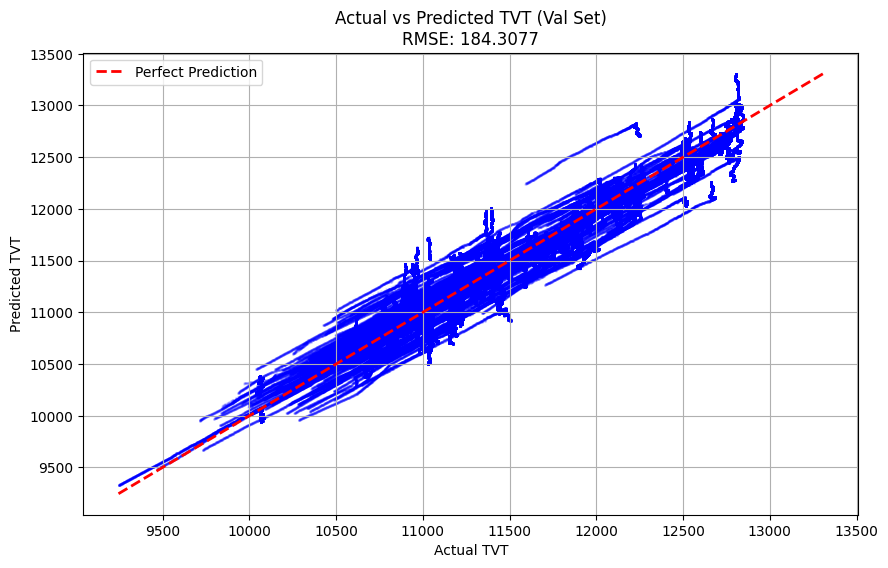

In [ ]:
def plot_pred_vs_actual(y_true, y_pred, val_rmse):
    """Plots predicted vs actual values on raw scale and saves it to analytics.

    Args:
        y_true: Ground truth values.
        y_pred: Model predictions.
        val_rmse: Validation RMSE score.
    """
    plt.figure(figsize=(10, 6))
    plt.scatter(np.array(y_true), np.array(y_pred), alpha=0.1, s=1, color="blue")

    # Draw perfect prediction line
    min_val = min(float(y_true.min()), float(y_pred.min()))
    max_val = max(float(y_true.max()), float(y_pred.max()))
    plt.plot(
        [min_val, max_val], [min_val, max_val], "r--", lw=2, label="Perfect Prediction"
    )

    plt.title(f"Actual vs Predicted TVT (Val Set)\nRMSE: {val_rmse:.4f}")
    plt.xlabel("Actual TVT")
    plt.ylabel("Predicted TVT")
    plt.legend()
    plt.grid(True)

    plt.savefig(os.path.join(ANALYTICS_DIR, "dense_opt_val_pred_vs_actual.png"))
    plt.show()


if "y_val_raw" in locals() and "yp_jnp" in locals():
    plot_pred_vs_actual(y_val_raw, yp_jnp, rmse)
